## 02 Physical Variables

Translates business variables into the physical state space of the dynamic system.

### Setup

In [1]:
import os
import sqlite3
import sys
import warnings
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, ROOT)
os.chdir(os.path.join(ROOT, 'notebooks'))

sys.path.insert(0, os.path.abspath('..'))
os.makedirs('../figures', exist_ok=True)

from src.features import build_physical_features, physical_summary, state_distribution  # noqa: E402
from src.visualization import PALETTE, plot_phase_space, set_style  # noqa: E402

set_style()

try:
    LIFELINES_OK = True
except Exception:
    LIFELINES_OK = False

DATA_DIR = os.path.join(ROOT, 'data')
df_clean = pd.read_csv(os.path.join(DATA_DIR, 'telco_clean.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'telco_features.csv'))
df_final = pd.read_csv(os.path.join(DATA_DIR, 'telco_final.csv'))
df = df_features.copy()
df_model = pd.get_dummies(df, columns=['Contract','PaymentMethod','InternetService'], drop_first=True)

# SQLite for notebooks that run SQL
conn = sqlite3.connect(':memory:')
df.to_sql('telco', conn, if_exists='replace', index=False)
df_clean.to_sql('telco_clean', conn, if_exists='replace', index=False)

print(f'Ready: {len(df):,} customers | churn rate {df.Churn_bin.mean():.1%}')

Ready: 7,043 customers | churn rate 26.5%


In [2]:
# Load real dataset
df_clean = pd.read_csv(os.path.join(DATA_DIR, 'telco_clean.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'telco_features.csv'))
df_final = pd.read_csv(os.path.join(DATA_DIR, 'telco_final.csv'))
df = df_features.copy()  

print(f'Dataset: {len(df):,} customers | Churn rate: {df["Churn_bin"].mean():.1%}')
print('Physical columns:', [c for c in df.columns if c in ['E0','E_eq','gamma','tau','resilience','physical_state','intrinsic_risk']])

Dataset: 7,043 customers | Churn rate: 26.5%
Physical columns: ['E_eq', 'gamma', 'tau', 'resilience', 'E0', 'physical_state', 'intrinsic_risk']


### Physical Feature Construction

In [3]:
df = build_physical_features(df)
print('Physical features generated:')
print(df[['tenure','MonthlyCharges','E0','gamma','tau','resilience','physical_state','Churn']].head(10).to_string())

Physical features generated:
   tenure  MonthlyCharges        E0   gamma       tau resilience physical_state Churn
0       1           29.85  0.294915  0.1658  6.031363        Low       Critical    No
1      34           56.95  0.795795  0.2258  4.428698     Medium         Stable    No
2       2           53.85  0.342084  0.2058  4.859086     Medium       Critical   Yes
3      45           42.30  0.801175  0.2658  3.762227       High         Stable    No
4       2           70.70  0.322107  0.1258  7.949126        Low       Critical   Yes
5       8           99.65  0.554780  0.1458  6.858711        Low        At risk   Yes
6      22           89.10  0.753903  0.1858  5.382131     Medium         Stable    No
7      10           29.75  0.621795  0.1858  5.382131     Medium        At risk    No
8      28          104.80  0.774679  0.1658  6.031363        Low         Stable   Yes
9      62           56.15  0.800080  0.2458  4.068348     Medium         Stable    No


### Distributions of E₀ and γ by churn

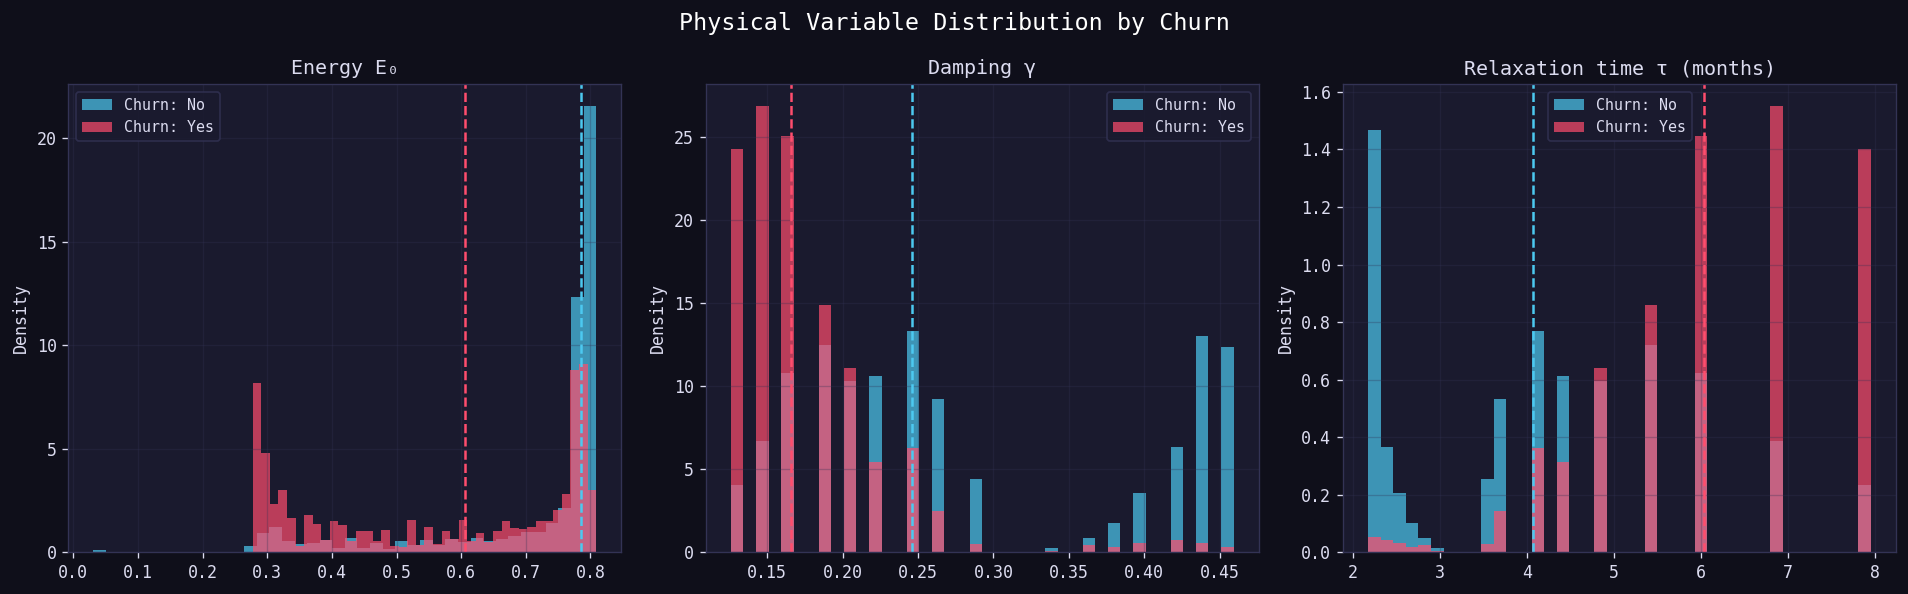

In [4]:
fig, axes = plt.subplots(1,3, figsize=(16,5))
fig.suptitle('Physical Variable Distribution by Churn', fontsize=14, color='white')

var_titles = [('E0','Energy E₀'), ('gamma','Damping γ'), ('tau','Relaxation time τ (months)')]
for ax, (var, titulo) in zip(axes, var_titles):
    for label, color in [('No', PALETTE['no_churn']), ('Yes', PALETTE['churn'])]:
        subset = df[df['Churn']==label][var]
        ax.hist(subset, bins=40, alpha=0.7, color=color, label=f'Churn: {label}', edgecolor='none', density=True)
        ax.axvline(subset.median(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(titulo)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '02_physical_distributions.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### Phase Diagram

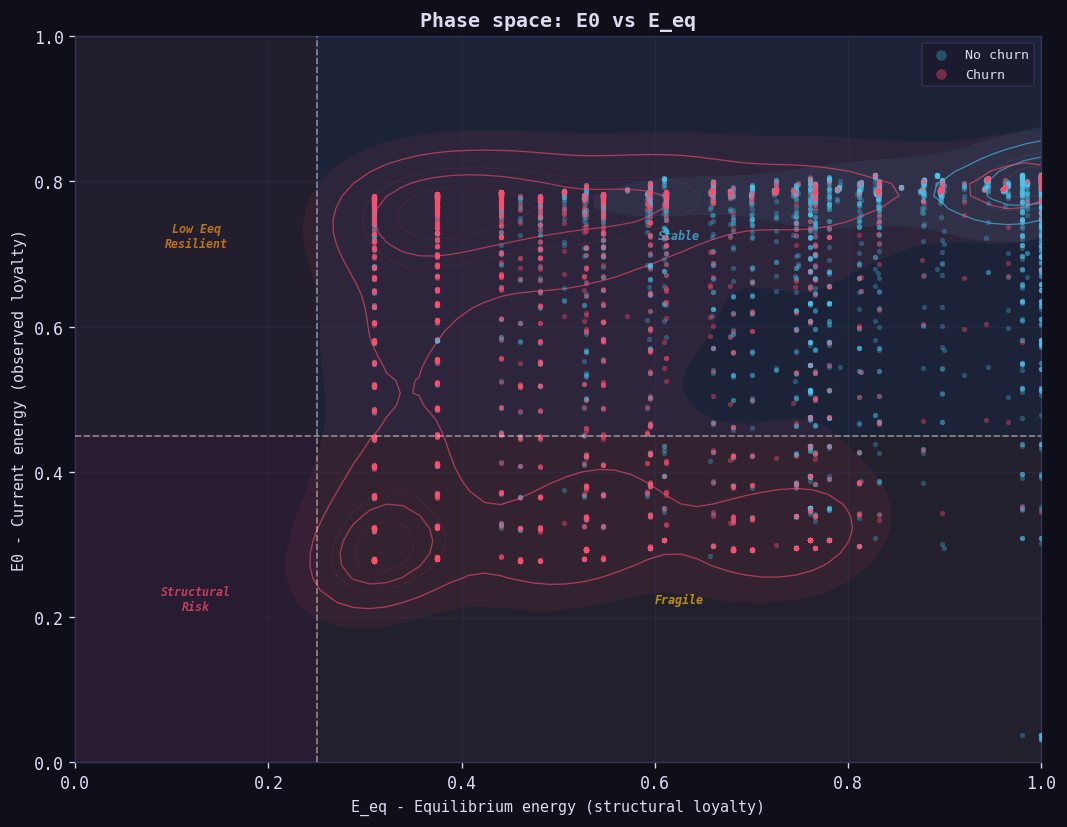

In [5]:
fig, ax = plt.subplots(figsize=(9,7))
plot_phase_space(df, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '02_phase_diagram.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### Comparative Statistical Summary

In [6]:
print('Physical variable summary: Churn vs No Churn')
physical_summary(df)

Physical variable summary: Churn vs No Churn


E0                    E_eq                   gamma                  \
         mean     std  median    mean     std  median    mean     std  median   
Churn                                                                           
No     0.7132  0.1514  0.7858  0.8031  0.2103  0.8319  0.2803  0.1118  0.2458   
Yes    0.5628  0.2026  0.6054  0.5344  0.1927  0.5060  0.1752  0.0533  0.1658   

          tau  ... num_services num_services_protective                 \
         mean  ...       median                    mean     std median   
Churn          ...                                                       
No     4.1658  ...          4.0                  1.3995  1.3540    1.0   
Yes    6.0895  ...          4.0                  0.8951  0.9896    1.0   

      num_services_entertainment                estimated_perturbation  \
                            mean     std median                   mean   
Churn                                                                    
No                        0.7358  0.8507    0.0                 0.0062   
Yes                       0.8732  0.8498    1.0                 0.0033   

                      
          std median  
Churn                 
No     0.1053    0.0  
Yes    0.0514    0.0  

[2 rows x 24 columns]

In [7]:
print('Physical state distribution')
state_distribution(df)

Physical state distribution


physical_state,At risk,Critical,Stable
Churn,,,
No,9.37,11.09,79.53
Yes,16.05,37.72,46.23


In [8]:
df.to_csv(os.path.join(DATA_DIR, 'telco_features.csv'), index=False)
print('Dataset with physical features saved to data/telco_features.csv')

Dataset with physical features saved to data/telco_features.csv


## Physical Variable Translation Table

| Business variable | Physical variable | Justification |
|---|---|---|
| tenure + services | Energy E₀ | Tenure and adhesion as accumulated energy |
| Contract + auto payment | Damping γ | System exit friction |
| 1/γ | Relaxation time τ | System response speed |
| Monthly/historical charge ratio | Perturbation F(t) | External load disrupting equilibrium |io |
